# PA4: Implementing linear classifiers
## Group 38

**Group Members:**
 - Sezin Kokum Mutludogan
 - Priyanka Machchhar 

## Task 1

Below we tried to train models with weather data. While first dataset performing very good, the second dataset gave 50% accuracy. To check the reason, we plotted the datasets.

In [1]:
import warnings

# Suppress FutureWarning from sklearn.pipeline module
warnings.filterwarnings("ignore", category=FutureWarning, module="sklearn.pipeline")

In [2]:
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import Perceptron
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
from sklearn.pipeline import make_pipeline

X1 = [{'city':'Gothenburg', 'month':'July'},
      {'city':'Gothenburg', 'month':'December'},
      {'city':'Paris', 'month':'July'},
      {'city':'Paris', 'month':'December'}]
Y1 = ['rain', 'rain', 'sun', 'rain']

X2 = [{'city':'Sydney', 'month':'July'},
      {'city':'Sydney', 'month':'December'},
      {'city':'Paris', 'month':'July'},
      {'city':'Paris', 'month':'December'}]
Y2 = ['rain', 'sun', 'sun', 'rain']

classifier1 = make_pipeline(DictVectorizer(), Perceptron(max_iter=10))
classifier1.fit(X1, Y1)
guesses1 = classifier1.predict(X1)
print(accuracy_score(Y1, guesses1))

classifier2 = make_pipeline(DictVectorizer(), Perceptron(max_iter=10))
#classifier2 = make_pipeline(DictVectorizer(), LinearSVC())
classifier2.fit(X2, Y2)
guesses2 = classifier2.predict(X2)
print(accuracy_score(Y2, guesses2))

1.0
0.5


Below is the graph of the first dataset. X axis is cities and Y axis is months. Colors of the points on the plot indicates the weather. When we look at the data, we can see that it can easily be separated with a straight line. Thus, the dataset is linearly separable and models can learn the pattern from this dataset.

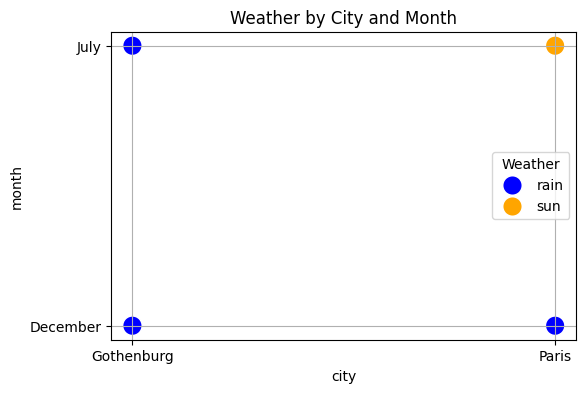

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.DataFrame(X1)
df["weather"] = Y1

color_map = {"sun": "orange", "rain": "blue"}

plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x="city", y="month", hue="weather", palette=color_map, s=200)

plt.title("Weather by City and Month")
plt.grid(True)
plt.legend(title="Weather")
plt.show()

In the plot below, we can see that it's not possible to separate two classes with a straight line. So, it's not linearly separable. This is why the models perform poor on this dataset.

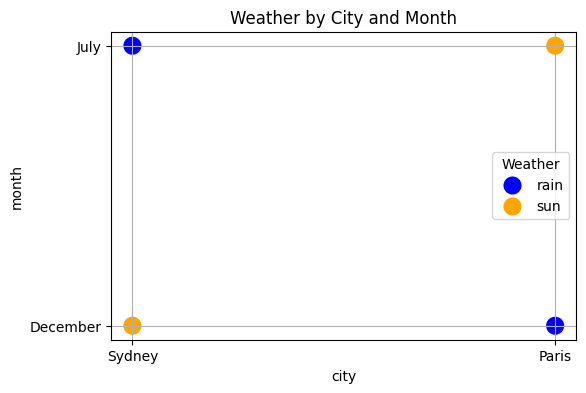

In [4]:
df = pd.DataFrame(X2)
df["weather"] = Y2

plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x="city", y="month", hue="weather", palette=color_map, s=200)

plt.title("Weather by City and Month")
plt.grid(True)
plt.legend(title="Weather")
plt.show()

## Task 2: Preparation for next tasks

Below we ran Perceptron code to prepare for the next tasks. It required a small change in `predict` function of `LinearClassifier`. `np.select` needed a default value so we gave `self.negative_class` as default value.

In [5]:
import numpy as np
from sklearn.base import BaseEstimator

class LinearClassifier(BaseEstimator):
    """
    General class for binary linear classifiers. Implements the predict
    function, which is the same for all binary linear classifiers. There are
    also two utility functions.
    """

    def decision_function(self, X):
        """
        Computes the decision function for the inputs X. The inputs are assumed to be
        stored in a matrix, where each row contains the features for one
        instance.
        """
        return X.dot(self.w)

    def predict(self, X):
        """
        Predicts the outputs for the inputs X. The inputs are assumed to be
        stored in a matrix, where each row contains the features for one
        instance.
        """

        # First compute the output scores
        scores = self.decision_function(X)

        # Select the positive or negative class label, depending on whether
        # the score was positive or negative.
        out = np.select([scores >= 0.0, scores < 0.0],
                        [self.positive_class,
                         self.negative_class],
                       default=self.negative_class)
        return out

    def find_classes(self, Y):
        """
        Finds the set of output classes in the output part Y of the training set.
        If there are exactly two classes, one of them is associated to positive
        classifier scores, the other one to negative scores. If the number of
        classes is not 2, an error is raised.
        """
        classes = sorted(set(Y))
        if len(classes) != 2:
            raise Exception("this does not seem to be a 2-class problem")
        self.positive_class = classes[1]
        self.negative_class = classes[0]

    def encode_outputs(self, Y):
        """
        A helper function that converts all outputs to +1 or -1.
        """
        return np.array([1 if y == self.positive_class else -1 for y in Y])


class Perceptron(LinearClassifier):
    """
    A straightforward implementation of the perceptron learning algorithm.
    """

    def __init__(self, n_iter=20):
        """
        The constructor can optionally take a parameter n_iter specifying how
        many times we want to iterate through the training set.
        """
        self.n_iter = n_iter

    def fit(self, X, Y):
        """
        Train a linear classifier using the perceptron learning algorithm.
        """

        # First determine which output class will be associated with positive
        # and negative scores, respectively.
        self.find_classes(Y)

        # Convert all outputs to +1 (for the positive class) or -1 (negative).
        Ye = self.encode_outputs(Y)

        # If necessary, convert the sparse matrix returned by a vectorizer
        # into a normal NumPy matrix.
        if not isinstance(X, np.ndarray):
            X = X.toarray()

        # Initialize the weight vector to all zeros.
        n_features = X.shape[1]
        self.w = np.zeros(n_features)

        # Perceptron algorithm:
        for i in range(self.n_iter):
            for x, y in zip(X, Ye):

                # Compute the output score for this instance.
                score = x.dot(self.w)

                # If there was an error, update the weights.
                if y*score <= 0:
                    self.w += y*x


When we trained the model with the given sentiment data, we got 79.19% accuracy with 0.61 seconds of training time. Thus, we validated that the code is working.

In [6]:
import time

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import Normalizer
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import SelectKBest
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split


# This function reads the corpus, returns a list of documents, and a list
# of their corresponding polarity labels. 
def read_data(corpus_file):
    X = []
    Y = []
    with open(corpus_file, encoding='utf-8') as f:
        for line in f:
            _, y, _, x = line.split(maxsplit=3)
            X.append(x.strip())
            Y.append(y)
    return X, Y
    
# Read all the documents.
X, Y = read_data('pa4/data/all_sentiment_shuffled.txt')

# Split into training and test parts.
Xtrain, Xtest, Ytrain, Ytest = train_test_split(X, Y, test_size=0.2, random_state=0)

# Set up the preprocessing steps and the classifier.
pipeline = make_pipeline(
    TfidfVectorizer(),
    SelectKBest(k=1000),
    Normalizer(),

    # NB that this is our Perceptron, not sklearn.linear_model.Perceptron
    Perceptron()  
)

# Train the classifier.
t0 = time.time()
pipeline.fit(Xtrain, Ytrain)
t1 = time.time()
print('Training time: {:.2f} sec.'.format(t1-t0))

# Evaluate on the test set.
Yguess = pipeline.predict(Xtest)
print('Accuracy: {:.4f}.'.format(accuracy_score(Ytest, Yguess)))


Training time: 0.61 sec.
Accuracy: 0.7919.


## Task 3: Implementing the SVC

Below we implement a support vector classifier according to the given Pegasos algorithm. It takes three parameters. `n_iter` is the number of epochs. `reg_param` is the regularization parameter `lambda` in the paper. `verbose` is to choose whether to print the loss in every epoch. `fit` function is defined according to Pegasos algorithm.

In [7]:
class SVC(LinearClassifier):
    def __init__(self, n_iter=10, reg_param=0.001, verbose=False):
        self.n_iter = n_iter
        self.reg_param = reg_param
        self.verbose = verbose

    def fit(self, X, Y):
        self.find_classes(Y)

        Ye = self.encode_outputs(Y)

        if not isinstance(X, np.ndarray):
            X = X.toarray()

        n_features = X.shape[1]
        self.w = np.zeros(n_features)

        for i in range(self.n_iter):
            t = 0
            total_loss = 0
            for x, y in zip(X, Ye):
                t = t + 1
                eta = 1 / (self.reg_param * t)

                score = x.dot(self.w)

                total_loss += max(0, 1 - y * score)

                if y*score < 1:
                    self.w = (1 - eta * self.reg_param) * self.w + (eta * y) * x
                else:
                    self.w = (1 - eta * self.reg_param) * self.w

            if self.verbose:
                print(f"Epoch {i:2d}, loss: {total_loss/len(X):.4f}")

To find the best hyperparameters we made grid search with cross-validation below. We tried 10, 20 and 50 for `n_iter` and 0.1, 0.01 and 0.001 for `reg_param`. We got the best accuracy with `n_iter = 10` and `reg_param = 0.001`.

In [8]:
from sklearn.model_selection import GridSearchCV

pipeline = make_pipeline(
    TfidfVectorizer(),
    SelectKBest(k=1000),
    Normalizer(),
    SVC()
)

param_grid = {
    'svc__n_iter': [10, 20, 50],
    'svc__reg_param': [0.1, 0.01, 0.001]
}

grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', verbose=1)
grid.fit(Xtrain, Ytrain)

print("Best parameters:", grid.best_params_)
print("Best CV score: {:.4f}".format(grid.best_score_))

Yguess = grid.predict(Xtest)
print("Test Accuracy: {:.4f}".format(accuracy_score(Ytest, Yguess)))

Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best parameters: {'svc__n_iter': 10, 'svc__reg_param': 0.001}
Best CV score: 0.8264
Test Accuracy: 0.8191


We set the best hyperparameters as default in the model and trained the model with these values. We got 81.91% accuracy which is above 80% with 0.67 seconds of training time.

In [9]:
pipeline = make_pipeline(
    TfidfVectorizer(),
    SelectKBest(k=1000),
    Normalizer(),
    SVC(verbose=True)
)

t0 = time.time()
pipeline.fit(Xtrain, Ytrain)
t1 = time.time()
print('Training time: {:.2f} sec.'.format(t1-t0))

Yguess = pipeline.predict(Xtest)
print('Accuracy: {:.4f}.'.format(accuracy_score(Ytest, Yguess)))

Epoch  0, loss: 0.5355
Epoch  1, loss: 0.5355
Epoch  2, loss: 0.5355
Epoch  3, loss: 0.5355
Epoch  4, loss: 0.5355
Epoch  5, loss: 0.5355
Epoch  6, loss: 0.5355
Epoch  7, loss: 0.5355
Epoch  8, loss: 0.5355
Epoch  9, loss: 0.5355
Training time: 0.67 sec.
Accuracy: 0.8191.


## Task 4: Logistic regression

We implemented logistic regression with Pegasos algorithm. We applied grid search again with the same values we did for SVC to find the best hyperparameters. Again, we got the best accuracy with `n_iter = 10` and `reg_param = 0.001`. We set these values as default in the model and trained the model. We got 80.82% accuracy and 0.87 seconds of training time.

In [10]:
class LogisticRegression(LinearClassifier):
    def __init__(self, n_iter=10, reg_param=0.001, verbose=False):
        self.n_iter = n_iter
        self.reg_param = reg_param
        self.verbose = verbose

    def fit(self, X, Y):
        self.find_classes(Y)

        Ye = self.encode_outputs(Y)

        if not isinstance(X, np.ndarray):
            X = X.toarray()

        n_features = X.shape[1]
        self.w = np.zeros(n_features)

        for i in range(self.n_iter):
            t = 0
            total_loss = 0
            for x, y in zip(X, Ye):
                t = t + 1
                eta = 1 / (self.reg_param * t)

                score = x.dot(self.w)

                total_loss += np.log(1 + np.exp(-y * score))

                gradient = y / (1 + np.exp(y * score)) * x
                self.w = (1 - eta * self.reg_param) * self.w + eta * gradient

            if self.verbose:
                print(f"Epoch {i:2d}, loss: {total_loss/len(X):.4f}")

In [11]:
pipeline = make_pipeline(
    TfidfVectorizer(),
    SelectKBest(k=1000),
    Normalizer(),
    LogisticRegression()
)

param_grid = {
    'logisticregression__n_iter': [10, 20, 50],
    'logisticregression__reg_param': [0.1, 0.01, 0.001]
}

grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', verbose=1)
grid.fit(Xtrain, Ytrain)

print("Best parameters:", grid.best_params_)
print("Best CV score: {:.4f}".format(grid.best_score_))

Yguess = grid.predict(Xtest)
print("Test Accuracy: {:.4f}".format(accuracy_score(Ytest, Yguess)))

Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best parameters: {'logisticregression__n_iter': 10, 'logisticregression__reg_param': 0.001}
Best CV score: 0.8120
Test Accuracy: 0.8082


In [12]:
pipeline = make_pipeline(
    TfidfVectorizer(),
    SelectKBest(k=1000),
    Normalizer(),
    LogisticRegression(verbose=True)
)

t0 = time.time()
pipeline.fit(Xtrain, Ytrain)
t1 = time.time()
print('Training time: {:.2f} sec.'.format(t1-t0))

Yguess = pipeline.predict(Xtest)
print('Accuracy: {:.4f}.'.format(accuracy_score(Ytest, Yguess)))

Epoch  0, loss: 0.5218
Epoch  1, loss: 0.5223
Epoch  2, loss: 0.5223
Epoch  3, loss: 0.5223
Epoch  4, loss: 0.5223
Epoch  5, loss: 0.5223
Epoch  6, loss: 0.5223
Epoch  7, loss: 0.5223
Epoch  8, loss: 0.5223
Epoch  9, loss: 0.5223
Training time: 0.87 sec.
Accuracy: 0.8082.


## Bonus task 1. Making your code more efficient

### (a) Faster linear algebra operations

We tried to speed up our code by using BLAS functions. For that, we defined a new SVC_BLAS class. It's the same as the previous SVC but it uses BLAS functions.

- We changed `x.dot(self.w)` to `ddot(x, self.w)` while calculating the score.
- We used `dscal(1 - eta * self.reg_param, self.w)` instead of `self.w = (1 - eta * self.reg_param) * self.w`.
- If `y*score` is less than 1, we used `daxpy(x, self.w, a=eta * y)` after using `dscal(1 - eta * self.reg_param, self.w)` for scaling. Thus we discarded `self.w = (1 - eta * self.reg_param) * self.w + (eta * y) * x` calculation in the previous SVC.

The accuracy stayed the same but when we checked the training time, we couldn't see what we expected. Training time is increased to 0.75 seconds from 0.67 seconds.

In [13]:
from scipy.linalg.blas import ddot, dscal, daxpy

class SVC_BLAS(LinearClassifier):
    def __init__(self, n_iter=10, reg_param=0.001, verbose=False):
        self.n_iter = n_iter
        self.reg_param = reg_param
        self.verbose = verbose

    def fit(self, X, Y):
        self.find_classes(Y)

        Ye = self.encode_outputs(Y)

        if not isinstance(X, np.ndarray):
            X = X.toarray()

        n_features = X.shape[1]
        self.w = np.zeros(n_features)

        for i in range(self.n_iter):
            t = 0
            total_loss = 0
            for x, y in zip(X, Ye):
                t = t + 1
                eta = 1 / (self.reg_param * t)

                score = ddot(x, self.w)

                total_loss += max(0, 1 - y * score)

                dscal(1 - eta * self.reg_param, self.w)

                if y*score < 1:
                    daxpy(x, self.w, a=eta * y)

            if self.verbose:
                print(f"Epoch {i+1:2d}, loss: {total_loss/len(X):.4f}")

In [14]:
pipeline = make_pipeline(
    TfidfVectorizer(),
    SelectKBest(k=1000),
    Normalizer(),
    SVC_BLAS(verbose=True)
)

t0 = time.time()
pipeline.fit(Xtrain, Ytrain)
t1 = time.time()
print('Training time: {:.2f} sec.'.format(t1-t0))

Yguess = pipeline.predict(Xtest)
print('Accuracy: {:.4f}.'.format(accuracy_score(Ytest, Yguess)))

Epoch  1, loss: 0.5355
Epoch  2, loss: 0.5355
Epoch  3, loss: 0.5355
Epoch  4, loss: 0.5355
Epoch  5, loss: 0.5355
Epoch  6, loss: 0.5355
Epoch  7, loss: 0.5355
Epoch  8, loss: 0.5355
Epoch  9, loss: 0.5355
Epoch 10, loss: 0.5355
Training time: 0.75 sec.
Accuracy: 0.8191.


### (b) Using sparse vectors

We disabled `SelectKBest(k=1000)` in the pipeline and added `ngram_range=(1,2)` to `TfidfVectorizer` to test sparse vectors. We trained both our regular SVC and SVC_BLAS with this pipeline. With this change, training time increased a lot and the accuracy is slightly decreased. But this time SVC_BLAS is trained faster than SVC. Training time for SVC is 89.68 seconds and for SVC_BLAS, it is 61.94 seconds.

In [15]:
pipeline = make_pipeline(
    TfidfVectorizer(ngram_range=(1,2)),
    # SelectKBest(k=1000),
    Normalizer(),
    SVC()
)

t0 = time.time()
pipeline.fit(Xtrain, Ytrain)
t1 = time.time()
print('Training time: {:.2f} sec.'.format(t1-t0))

Yguess = pipeline.predict(Xtest)
print('Accuracy: {:.4f}.'.format(accuracy_score(Ytest, Yguess)))

Training time: 89.68 sec.
Accuracy: 0.8107.


In [16]:
pipeline = make_pipeline(
    TfidfVectorizer(ngram_range=(1,2)),
    # SelectKBest(k=1000),
    Normalizer(),
    SVC_BLAS()
)

t0 = time.time()
pipeline.fit(Xtrain, Ytrain)
t1 = time.time()
print('Training time: {:.2f} sec.'.format(t1-t0))

Yguess = pipeline.predict(Xtest)
print('Accuracy: {:.4f}.'.format(accuracy_score(Ytest, Yguess)))

Training time: 61.94 sec.
Accuracy: 0.8107.


To improve the training time, we defined `SparseSVC` below. We used `add_sparse_to_dense` and `sparse_dense_dot` functions from the lesson. 

- We used `sparse_dense_dot(x, self.w)` instead of `ddot(x, self.w)` for calculating the score.
- We used `add_sparse_to_dense(x, self.w, eta * y)` instead of `daxpy(x, self.w, a=eta * y)`.

This has changed the training time dramatically. It reduced to 7.60 seconds from 61.94 seconds while the accuracy is staying the same.

In [17]:
def add_sparse_to_dense(x, w, factor):
    """
    Adds a sparse vector x, scaled by some factor, to a dense vector.
    This can be seen as the equivalent of w += factor * x when x is a dense
    vector.
    """
    w[x.indices] += factor * x.data


def sparse_dense_dot(x, w):
    """
    Computes the dot product between a sparse vector x and a dense vector w.
    """
    return np.dot(w[x.indices], x.data)


class SparseSVC(LinearClassifier):
    def __init__(self, n_iter=10, reg_param=0.001, verbose=False):
        self.n_iter = n_iter
        self.reg_param = reg_param
        self.verbose = verbose

    def fit(self, X, Y):
        self.find_classes(Y)

        Ye = self.encode_outputs(Y)

        self.w = np.zeros(X.shape[1])

        XY = list(zip(X, Ye))

        for i in range(self.n_iter):
            t = 0
            total_loss = 0
            for x, y in XY:
                t = t + 1
                eta = 1 / (self.reg_param * t)

                score = sparse_dense_dot(x, self.w)

                total_loss += max(0, 1 - y * score)

                self.w *= (1 - eta * self.reg_param)

                if y*score < 1:
                    add_sparse_to_dense(x, self.w, eta * y)

            if self.verbose:
                print(f"Epoch {i:2d}, loss: {total_loss/X.shape[0]:.4f}")

In [18]:
pipeline = make_pipeline(
    TfidfVectorizer(ngram_range=(1,2)),
    # SelectKBest(k=1000),
    Normalizer(),
    SparseSVC(verbose=True)
)

t0 = time.time()
pipeline.fit(Xtrain, Ytrain)
t1 = time.time()
print('Training time: {:.2f} sec.'.format(t1-t0))

Yguess = pipeline.predict(Xtest)
print('Accuracy: {:.4f}.'.format(accuracy_score(Ytest, Yguess)))

Epoch  0, loss: 0.7125
Epoch  1, loss: 0.7125
Epoch  2, loss: 0.7125
Epoch  3, loss: 0.7125
Epoch  4, loss: 0.7125
Epoch  5, loss: 0.7125
Epoch  6, loss: 0.7125
Epoch  7, loss: 0.7125
Epoch  8, loss: 0.7125
Epoch  9, loss: 0.7125
Training time: 7.60 sec.
Accuracy: 0.8107.


### (c) Speeding up the scaling operation

We implemented ScaledSparseSVC to use the scaling operation trick described in the paper and in the clarification document. We used scaling factor `a`, and instead of scaling the vector in each operation, we changed scaling factor `a`. After the training is done, we scaled the weight vector with `a`. To avoid `a` becoming zero and causing the division by zero problem, we added a small regularization value (1e-10) to `t` in `eta = 1 / (self.reg_param * (t + 1e-10))` step.

After the training, the accuracy stayed the same but the training time improved even when compared to `SparseSVC`. It reduced from 7.60 seconds to 1.87 seconds.

In [19]:
def add_sparse_to_dense(x, w, factor):
    """
    Adds a sparse vector x, scaled by some factor, to a dense vector.
    This can be seen as the equivalent of w += factor * x when x is a dense
    vector.
    """
    w[x.indices] += factor * x.data


def sparse_dense_dot(x, w):
    """
    Computes the dot product between a sparse vector x and a dense vector w.
    """
    return np.dot(w[x.indices], x.data)


class ScaledSparseSVC(LinearClassifier):
    def __init__(self, n_iter=10, reg_param=0.001, verbose=False):
        self.n_iter = n_iter
        self.reg_param = reg_param
        self.verbose = verbose

    def fit(self, X, Y):
        self.find_classes(Y)

        Ye = self.encode_outputs(Y)

        self.w = np.zeros(X.shape[1])

        XY = list(zip(X, Ye))

        a = 1.0

        for i in range(self.n_iter):
            t = 0
            total_loss = 0
            for x, y in XY:
                t = t + 1
                eta = 1 / (self.reg_param * (t + 1e-10))
                
                score = a * sparse_dense_dot(x, self.w)

                a *= (1 - eta * self.reg_param)

                total_loss += max(0, 1 - y * score)

                if y*score < 1:
                    add_sparse_to_dense(x, self.w, (eta * y) / a)

            if self.verbose:
                print(f"Epoch {i:2d}, loss: {total_loss/X.shape[0]:.4f}")

        self.w *= a

In [20]:
pipeline = make_pipeline(
    TfidfVectorizer(ngram_range=(1,2)),
    # SelectKBest(k=1000),
    Normalizer(),
    ScaledSparseSVC(verbose=True)
)

t0 = time.time()
pipeline.fit(Xtrain, Ytrain)
t1 = time.time()
print('Training time: {:.2f} sec.'.format(t1-t0))

Yguess = pipeline.predict(Xtest)
print('Accuracy: {:.4f}.'.format(accuracy_score(Ytest, Yguess)))

Epoch  0, loss: 0.7125
Epoch  1, loss: 0.7125
Epoch  2, loss: 0.7125
Epoch  3, loss: 0.7125
Epoch  4, loss: 0.7125
Epoch  5, loss: 0.7125
Epoch  6, loss: 0.7125
Epoch  7, loss: 0.7125
Epoch  8, loss: 0.7125
Epoch  9, loss: 0.7125
Training time: 1.87 sec.
Accuracy: 0.8107.
